In [8]:
import joblib
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [9]:
# Load processed data

x_train = joblib.load(
    "processed_data/x_train_resampled.pkl"
)

x_test = joblib.load(
    "processed_data/x_test_scaled.pkl"
)


y_train = joblib.load(
    "processed_data/y_train_resampled.pkl"
)

y_test = joblib.load(
    "processed_data/y_test.pkl"
)

print("data loaded successfully")

data loaded successfully


In [10]:
# define models

models = {

    "Logistic Regression":
       LogisticRegression(
          max_iter=1000,
          random_state=42
       ),

    "Naive Bayes":
       GaussianNB(),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        )
}

In [11]:
# Train and evaluate all models

results = []

trained_models = {}

for name, model in models.items():

    print(f"\Training {name}...")

    model.fit(x_train, y_train)

    trained_models[name] = model
     
    y_pred = model.predict(x_test)

    y_prob = model.predict_proba(x_test)[:, 1]

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        auc
    ])

print("Training completed")

\Training Logistic Regression...
\Training Naive Bayes...
\Training Decision Tree...
\Training Random Forest...
Training completed


In [12]:
# comparison table

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
)

results_df.sort_values(
    by="Recall",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.98952,0.801964,0.98000,0.882088,0.999179
3,Random Forest,0.99821,0.981598,0.97350,0.977532,0.998299
2,Decision Tree,0.99612,0.938350,0.96650,0.952217,0.981927
1,Naive Bayes,0.99635,0.991881,0.91625,0.952567,0.998644


In [13]:
# best model

results_df.sort_values(
    by="Recall",
    ascending=False
).head(1)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.98952,0.801964,0.98,0.882088,0.999179


In [14]:
# detailed report for model

best_model = trained_models[
    "Random Forest"
]

y_pred = best_model.predict(x_test)

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     96000
           1       0.98      0.97      0.98      4000

    accuracy                           1.00    100000
   macro avg       0.99      0.99      0.99    100000
weighted avg       1.00      1.00      1.00    100000



Text(45.722222222222214, 0.5, 'Actual')

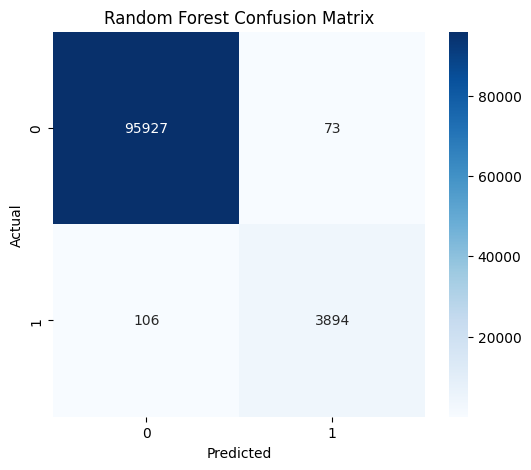

In [15]:
# confusion matrix

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

In [16]:
joblib.dump(
    best_model,
    "model_artifacts/fraud_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [17]:
results_df.to_csv(
    "model_comparison.csv",
    index=False
)

print("Comparison Table Saved")

Comparison Table Saved
